In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

In [12]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["font.size"] = 30

plt.rcParams["mathtext.fontset"] = "stix"

### Transmonin määrittely

In [3]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [4]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [5]:
A=12.060132973240993
f_d_AC_stark=-0.3072898535663432
s1_middle = 7.6939006231366305
s2_middle = 14.166338450511766

## Simulaatio

In [6]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus
f_d=qubit.frequency/3
f_rabi=2*np.pi/40

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [7]:
def find_drive_frequency(A,evolution,f_rabi,lims,scale,s1,s2):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=f_d_AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = pulses.sim_3_part_pulses(f_d+delta,s1,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True,s2=s2)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (10⁹rad/s)")
    plt.ylabel("E-tason suurin todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

def find_params(f_d,A,evolution,f_rabi,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_s1 = lims[0][0]
    max_range_s1 = lims[0][1]

    min_range_s2 = lims[1][0]
    max_range_s2 = lims[1][1]
    
    e_data=[]
    f_data=[]
    
    s1_vals=np.arange(min_range_s1,max_range_s1)/scales[0] + s1_middle
    s2_vals=np.arange(min_range_s2,max_range_s2)/scales[1] + s2_middle
    
    for i in range(min_range_s1,max_range_s1):
        s1 = i/scales[0] + s1_middle
        
        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_s2,max_range_s2):

            s2 = j/scales[1] + s2_middle
    
            sim_vals = pulses.sim_3_part_pulses(f_d+f_d_AC_stark,s1,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True,s2=s2)
    
            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(s1_vals)
    ytick_locs=np.arange(0,1, step=0.2)*len(s2_vals)

    xlabels=[round(s1_vals[int(i)],3) for i in xtick_locs]
    ylabels=[round(s2_vals[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    min_index = np.unravel_index(np.argmin(f_data), np.array(f_data).shape)
    
    s1=s1_vals[min_index[0]]
    s2=s2_vals[min_index[1]]
    
    return(s1,s2)

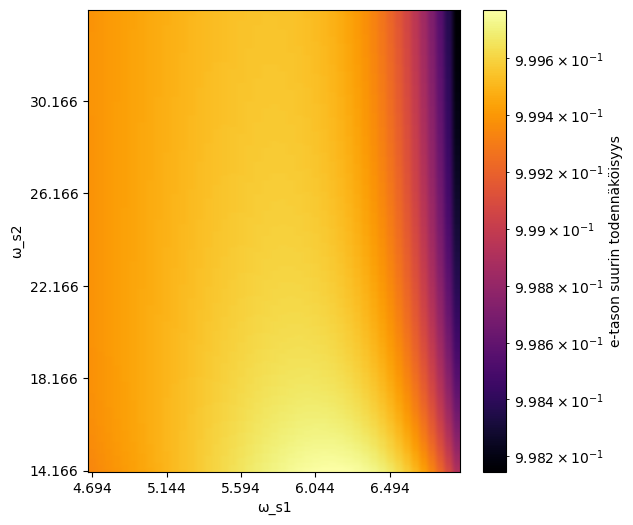

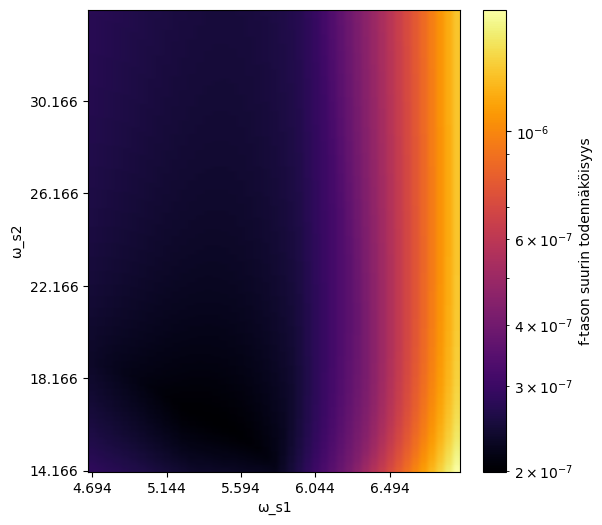

[[np.float64(0.9993425967144666), np.float64(0.9993446621610494), np.float64(0.999346618775353), np.float64(0.999348473640193), np.float64(0.9993502332834167), np.float64(0.999351903728818), np.float64(0.9993534905414688), np.float64(0.9993549988687856), np.float64(0.9993564334770442), np.float64(0.9993577987845104), np.float64(0.9993590988910249), np.float64(0.9993603376049479), np.float64(0.9993615184673398), np.float64(0.9993626447739509), np.float64(0.9993637195950706), np.float64(0.9993647457935443), np.float64(0.9993657260411309), np.float64(0.9993666628336083), np.float64(0.9993675585040455), np.float64(0.999368415235388), np.float64(0.9993692350717867), np.float64(0.9993700199287086), np.float64(0.9993707716026158), np.float64(0.9993714917795613), np.float64(0.9993721820429653), np.float64(0.9993728438811235), np.float64(0.9993734786938149), np.float64(0.9993740877983318), np.float64(0.9993746724353996), np.float64(0.9993752337740932), np.float64(0.9993757729169059), np.float64

Amplitudi (GHz): 12.060132973240993
Ensimmäinen hiljennetty taajuus (10⁹ rad/s): 5.393900623136631
Toinen hiljennetty taajuus (10⁹ rad/s): 16.466338450511767
E-tason suurin todennäköisyys: 0.9996984250749629
F-tason suurin todennäköisyys: 8.032896157448329e-07


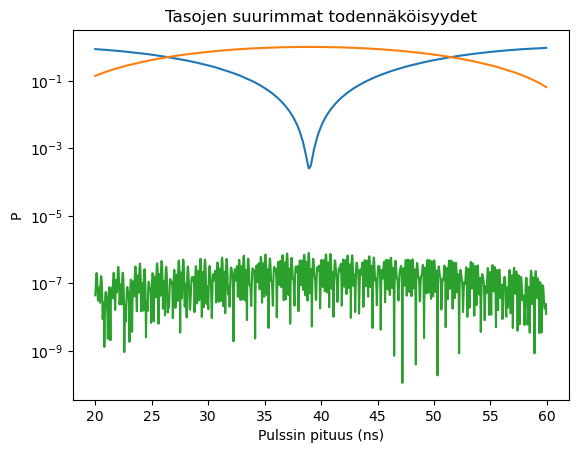

---------------------------------------------


In [7]:
s1_vals=[]
s2_vals=[]

params=find_params(f_d,A,evolution_eigenbasis,f_rabi,[[-60,-15],[0,200]],[20,10])
s1_vals.append(params[0])
s2_vals.append(params[1])

m=1

vals = pulses.sim_3_part_pulses(f_d+f_d_AC_stark,s1_vals[-1],A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=0,drag=True,s2=s2_vals[-1])

print("Amplitudi (GHz):", A)

print("Ensimmäinen hiljennetty taajuus (10⁹ rad/s):", s1_vals[-1])
print("Toinen hiljennetty taajuus (10⁹ rad/s):", s2_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

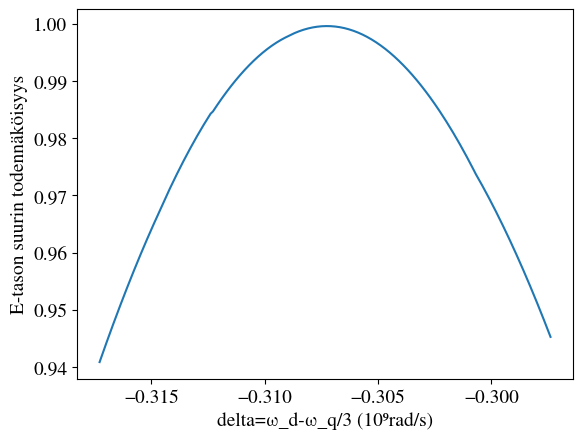

Amplitudi (GHz): 12.060132973240993
AC-stark siirtymä (GHz): -0.3072898535663432
E-tason suurin todennäköisyys: 0.9995781091857013
F-tason suurin todennäköisyys: 1.9945405845236587e-07
Pulssin pituus (ns): 38.41471406409907


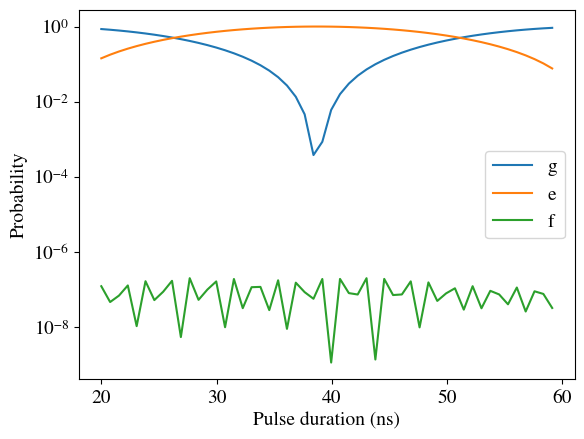

---------------------------------------------


In [8]:
params=find_drive_frequency(A, evolution_eigenbasis,f_rabi,[-100,100],10000,5.393900623136631,16.466338450511767)

f_d_opt = qubit.frequency/3+params[0] #Löydetty optimaalinen ajotaajuus

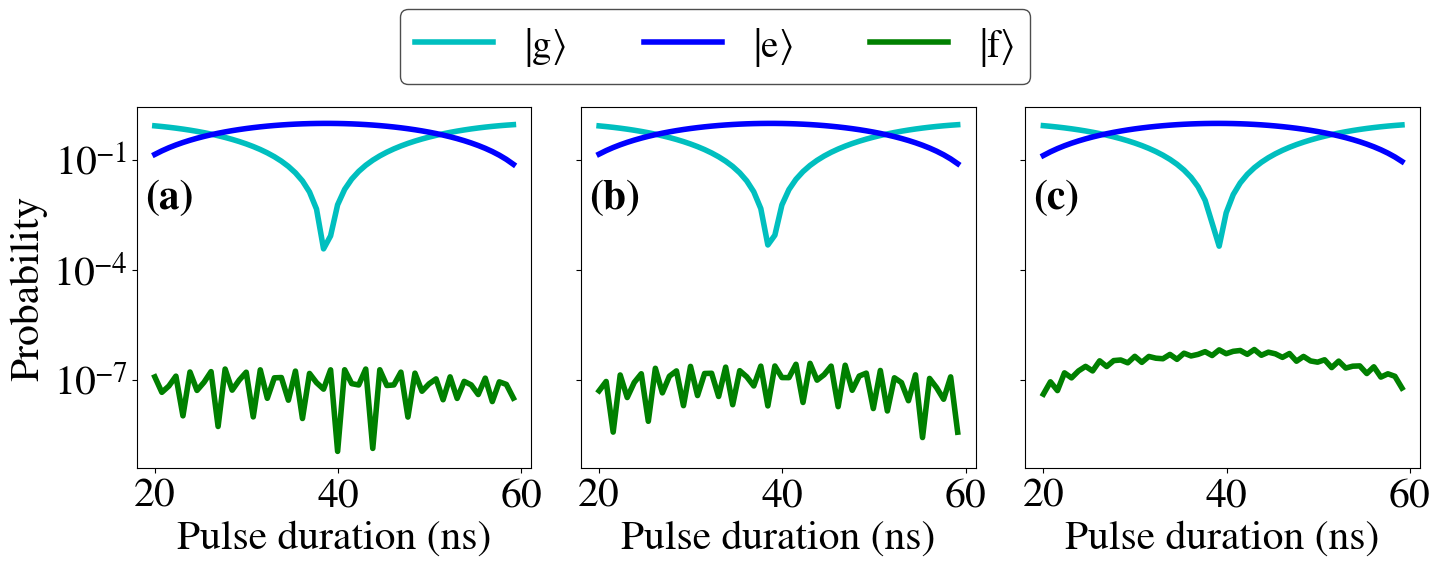

In [15]:
m = 1

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 6))

f_d_opt = qubit.frequency/3 - 0.3072898535663432

vals = pulses.sim_3_part_pulses(
    f_d_opt,
    5.393900623136631,
    A,
    evolution_eigenbasis,
    dim,
    f_rabi/m,
    t_ramp=10,
    U_f=1,
    drag=True,
    s2=16.466338450511767
)

g_vals = np.array([arr[0] for arr in vals[3]])
e_vals = np.array([arr[1] for arr in vals[3]])
f_vals = np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3]) / m)

l1, = axes[0].semilogy(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
l2, = axes[0].semilogy(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
l3, = axes[0].semilogy(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')

axes[0].set_xlabel("Pulse duration (ns)")
axes[0].set_ylabel("Probability")
axes[0].set_yticks([1, 1e-3, 1e-6, 1e-9])

axes[0].text(
    0.02, 0.80, "(a)",
    transform=axes[0].transAxes,
    va="top",
    fontweight="bold"
)

vals = pulses.sim_3_part_pulses(
    f_d_opt,
    5.393900623136631,
    A,
    evolution_eigenbasis,
    dim,
    f_rabi/m,
    t_ramp=10,
    U_f=1,
    drag=True
)

g_vals = np.array([arr[0] for arr in vals[3]])
e_vals = np.array([arr[1] for arr in vals[3]])
f_vals = np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3]) / m)

axes[1].semilogy(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
axes[1].semilogy(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
axes[1].semilogy(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')

axes[1].set_xlabel("Pulse duration (ns)")

axes[1].text(
    0.02, 0.80, "(b)",
    transform=axes[1].transAxes,
    va="top",
    fontweight="bold"
)

vals = pulses.sim_3_part_pulses(
    f_d + f_d_AC_stark,
    0,
    A,
    evolution_eigenbasis,
    dim,
    f_rabi/m,
    t_ramp=10,
    U_f=1,
    drag=False
)

g_vals = np.array([arr[0] for arr in vals[3]])
e_vals = np.array([arr[1] for arr in vals[3]])
f_vals = np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3]) / m)

axes[2].semilogy(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
axes[2].semilogy(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
axes[2].semilogy(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')

axes[2].set_xlabel("Pulse duration (ns)")

axes[2].text(
    0.02, 0.80, "(c)",
    transform=axes[2].transAxes,
    va="top",
    fontweight="bold"
)

fig.legend(
    [l1, l2, l3],
    [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=28,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("sub-pulses.pdf")
plt.show()

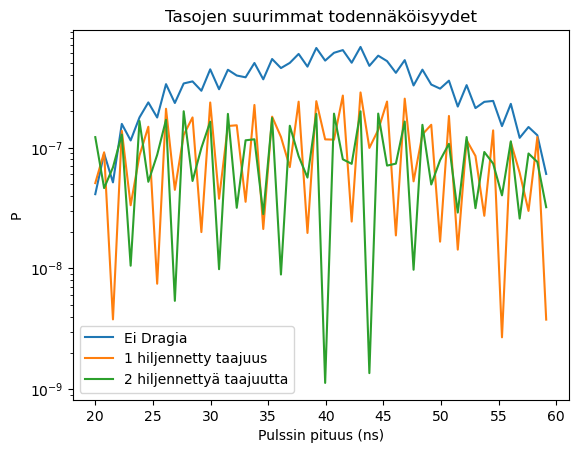

---------------------------------------------


In [ ]:
vals1 = pulses.sim_3_part_pulses(f_d+f_d_AC_stark,5.393900623136631,A,evolution_eigenbasis,dim,f_rabi,t_ramp=10,U_f=1,drag=False)
vals2 = pulses.sim_3_part_pulses(f_d+f_d_AC_stark,5.393900623136631,A,evolution_eigenbasis,dim,f_rabi,t_ramp=10,U_f=1,drag=True)
vals3 = pulses.sim_3_part_pulses(f_d+f_d_AC_stark,5.393900623136631,A,evolution_eigenbasis,dim,f_rabi,t_ramp=10,U_f=1,drag=True,s2=16.466338450511767)

f_vals1=np.array([arr[2] for arr in vals1[3]])
f_vals2=np.array([arr[2] for arr in vals2[3]])
f_vals3=np.array([arr[2] for arr in vals3[3]])

plt.figure()
plt.semilogy(vals1[4][:n_picked], f_vals1)
plt.semilogy(vals2[4][:n_picked], f_vals2)
plt.semilogy(vals3[4][:n_picked], f_vals3)
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.legend(["Ei Dragia", "1 hiljennetty taajuus", "2 hiljennettyä taajuutta"])
plt.show()

print("---------------------------------------------")